In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd

from robin.kernel.entities import Kernel

In [ ]:
path_config_supply = '../data/MAD-BCN/supply_MAD-BCN_2025.yaml'
path_config_demand = '../data/MAD-BCN/demand_data.yaml'
path_kernel_output = '../data/MAD-BCN/kernel_output'
kernel_output_file = 'output.csv'

path_prices_data = '../data/MAD-BCN/prices/prices_MAD-BCN_2025.csv'
figures_path = '../figures/MAD-BCN'

os.makedirs(path_kernel_output, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)

# Set the random seed for reproducibility
seed = 2025


In [4]:
kernel = Kernel(path_config_supply, path_config_demand)
services = kernel.simulate(os.path.join(path_kernel_output, kernel_output_file),
                            seed=seed,
                            departure_time_hard_restriction=False,
                            calculate_global_utility=True)


In [5]:
# Merge the kernel output with the name of the selected service
kernel_output = pd.read_csv(os.path.join(path_kernel_output, kernel_output_file))
prices_data = pd.read_csv(path_prices_data)
kernel_output = kernel_output.merge(prices_data[['service_id', 'train_type']], left_on='service', right_on='service_id', how='left')

# Save the merged data to a new CSV file
output_file = os.path.join(path_kernel_output, 'output_with_service.csv')
kernel_output.to_csv(output_file, index=False)

# Display the first few rows of the merged DataFrame
kernel_output.head(5)

,id,user_pattern,departure_station,arrival_station,arrival_day,arrival_time,purchase_date,service,service_departure_time,service_arrival_time,seat,price,utility,best_service,best_seat,best_utility,service_id,train_type
0,36209,Leisure-Evening,60000,71801,2025-01-03,21.807117,2024-12-09,00009_03-01-2025-20.22,20.366667,23.233333,BasicSeat,23.97,6.310020,00009_03-01-2025-20.22,BasicSeat,6.310020,00009_03-01-2025-20.22,IRYO
1,5450,Leisure-Evening,60000,71801,2025-01-01,22.361273,2024-12-10,00020_01-01-2025-20.27,20.450000,23.800000,BasicSeat,32.28,6.663962,00020_01-01-2025-20.27,BasicSeat,6.663962,00020_01-01-2025-20.27,AVE
2,6286,Leisure-Morning,60000,71801,2025-01-01,10.126492,2024-12-10,00009_01-01-2025-09.22,9.366667,12.233333,BasicSeat,24.08,6.710169,00009_01-01-2025-09.22,BasicSeat,6.710169,00009_01-01-2025-09.22,IRYO
3,11144,Leisure-Morning,60000,71801,2025-01-01,15.023592,2024-12-10,00004_01-01-2025-14.57,14.950000,17.566667,BasicSeat,32.05,7.211952,00004_01-01-2025-14.57,BasicSeat,7.211952,00004_01-01-2025-14.57,AVE
4,25874,Leisure-Evening,60000,71801,2025-01-02,22.485183,2024-12-10,00005_02-01-2025-21.02,21.033333,23.900000,BasicSeat,32.42,6.649426,00005_02-01-2025-21.02,BasicSeat,6.649426,00005_02-01-2025-21.02,OUIGO


## Plot some visualizations of the data synthetic data generated

Total number of tickets sold: 4314747
Tickets sold per train type:
train_type
AVE        1557110
IRYO       1483908
OUIGO       718051
AVLO        497801
AVE INT      57877
Name: count, dtype: int64


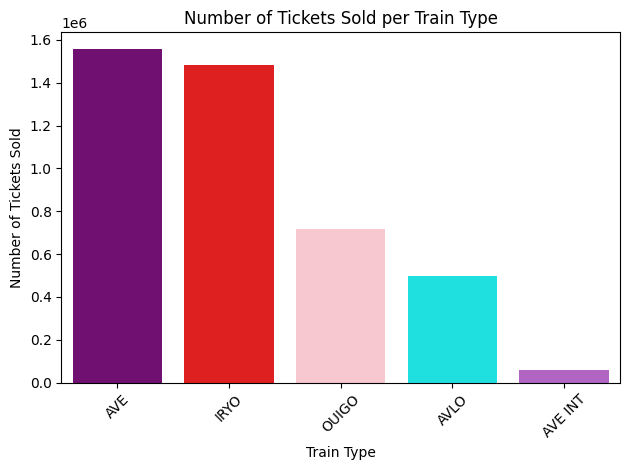

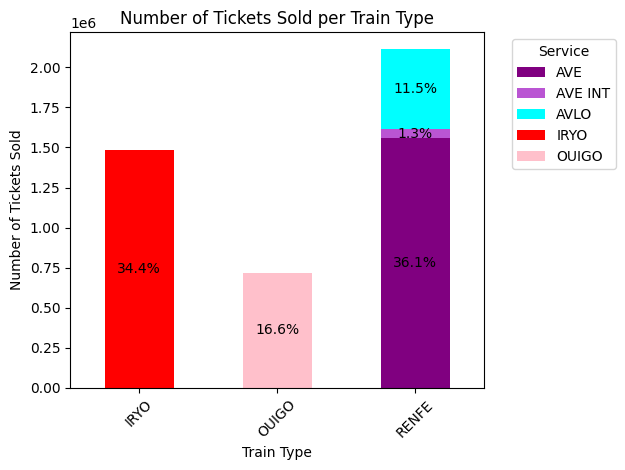

In [6]:
# Get the tickets sold per train type
tickets_per_train = kernel_output['train_type'].value_counts()

# Display the summary
total_tickets = tickets_per_train.sum()
print(f'Total number of tickets sold: {total_tickets}')
print('Tickets sold per train type:')
print(tickets_per_train)




# Define a color map for each service
color_map = {
    'AVE': 'purple',
    'AVE INT': '#BA55D3',  # Medium Orchid
    'AVLO': 'aqua',
    'OUIGO': 'pink',
    'IRYO': 'red'
}
# Any other service that appears will use 'grey'
colors = [color_map.get(s, 'grey') for s in tickets_per_train.index]


## Figure 1: Tickets sold per train type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.barplot(
    x=tickets_per_train.index,
    y=tickets_per_train.values,
    hue=tickets_per_train.index,
    palette=colors,
    legend=False
)
plt.title('Number of Tickets Sold per Train Type')
plt.xlabel('Train Type')
plt.ylabel('Number of Tickets Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Figure 2: Tickets sold per train type aggregating RENFE services
kernel_output['train_type_agg'] = kernel_output.apply(
    lambda row: 'RENFE' if row['train_type'] in ['AVLO', 'AVE', 'AVE INT'] else row['train_type'],
    axis=1
)

tickets_per_train = (
    kernel_output
    .groupby(['train_type_agg', 'train_type'])
    .size()
    .unstack(fill_value=0)
)

stacked_colors = [
    color_map.get(service, 'grey')
    for service in tickets_per_train.columns
]

# Dibujar la barra apilada con colores personalizados
plt.figure()
tickets_per_train.plot(
    kind='bar',
    stacked=True,
    color=stacked_colors,
    ax=plt.gca()
)

# Dibujar en medio de cada gráfica el porcentaje de cada servicio 
total = tickets_per_train.sum().sum()
for i, (train_type, row) in enumerate(tickets_per_train.iterrows()):
    #total = row.sum()
    for j, (service, count) in enumerate(row.items()):
        if count > 0:
            percentage = count / total * 100
            plt.text(i, row[:j + 1].sum() - count / 2, f'{percentage:.1f}%', ha='center', va='center', color='black')

plt.title('Number of Tickets Sold per Train Type')
plt.xlabel('Train Type')
plt.ylabel('Number of Tickets Sold')
plt.xticks(rotation=45)
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'tickets_per_train_type.png'), bbox_inches='tight')
plt.show()

The demand simulated in this notebook is based on the real demand of the MAD-BCN corridor in 2024, as reported by the
_Comisión Nacional de los Mercados y la Competencia_ (CNMC).
This demand was of approximately 8.69 million passengers for the year. However, the demand is divided by two to account 
only for the MAD-BCN direction, since the opposite direction is not considered in this simulation. Therefore, the total demand considered in this simulation is approximately 4 million passengers for the MAD-BCN direction.

The distribution of users across market segments and the behavioral parameters used in the utility functions are calibrated to produce realistic results consistent with the Spanish high-speed rail market. Nevertheless, the values used should not be interpreted as exact estimations of real passenger preferences. A precise calibration would require access to detailed ticket sales and booking data from each rail operator, including prices, schedules, and observed passenger choices, which are commercially sensitive and confidential information not publicly available. Therefore, the parameters used in this simulation are adjusted
to approximate the observed market shares and demand levels reported by the CNMC, while ensuring that the resulting demand patterns are plausible and consistent with known market trends.


<u>**Real demand of the MAD – BCN corridor in 2024**</u>

**Total demand:** **8 690 000** passengers

| Service | Passengers  | % of total |
|:--------|------------:|-----------:|
| Renfe   |   4 051 719 |      46.6% |
| Ouigo   |   1 616 947 |      18.6% |
| Iryo    |   3 008 843 |      34.6% |


Demand by train type:

| Train type    | % of total |
|:--------------|-----------:|
| AVE + AVE INT |      36.3% |
| AVLO          |      10.3% |
| Ouigo         |      18.6% |
| Iryo          |      34.8% |


* Data obtained from the annual report on the railway sector by the Comisión Nacional de los Mercados y la Competencia (CNMC).


In [7]:
from robin.plotter.entities import KernelPlotter

kernel_plotter = KernelPlotter(
    path_output_csv=os.path.join(path_kernel_output, kernel_output_file),
    path_config_supply=path_config_supply,
)

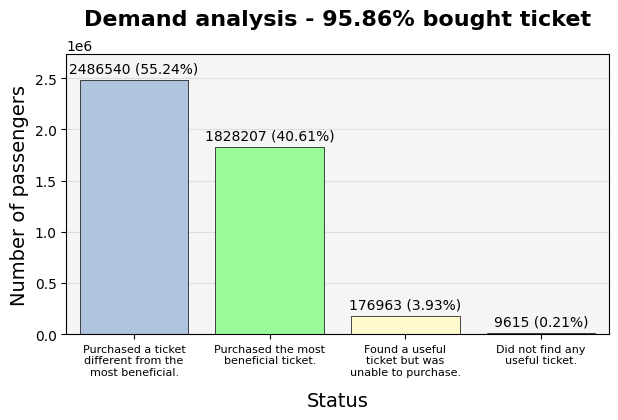

In [8]:
# Plot an analysis of the demand
kernel_plotter.plot_demand_status(save_path=f'{figures_path}/demand_status.pdf')

In [9]:
# Plot the distribution of all the seat types
#kernel_plotter.plot_seat_distribution_pie_chart(save_path=f'{figures_path}/pie.pdf')

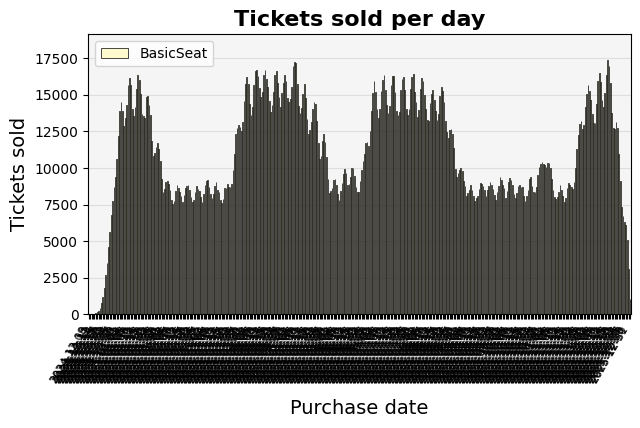

In [10]:
# Plot the distribution of the tickets sold by date
kernel_plotter.plot_tickets_by_date(save_path=f'{figures_path}/total_tickets_sold.pdf')

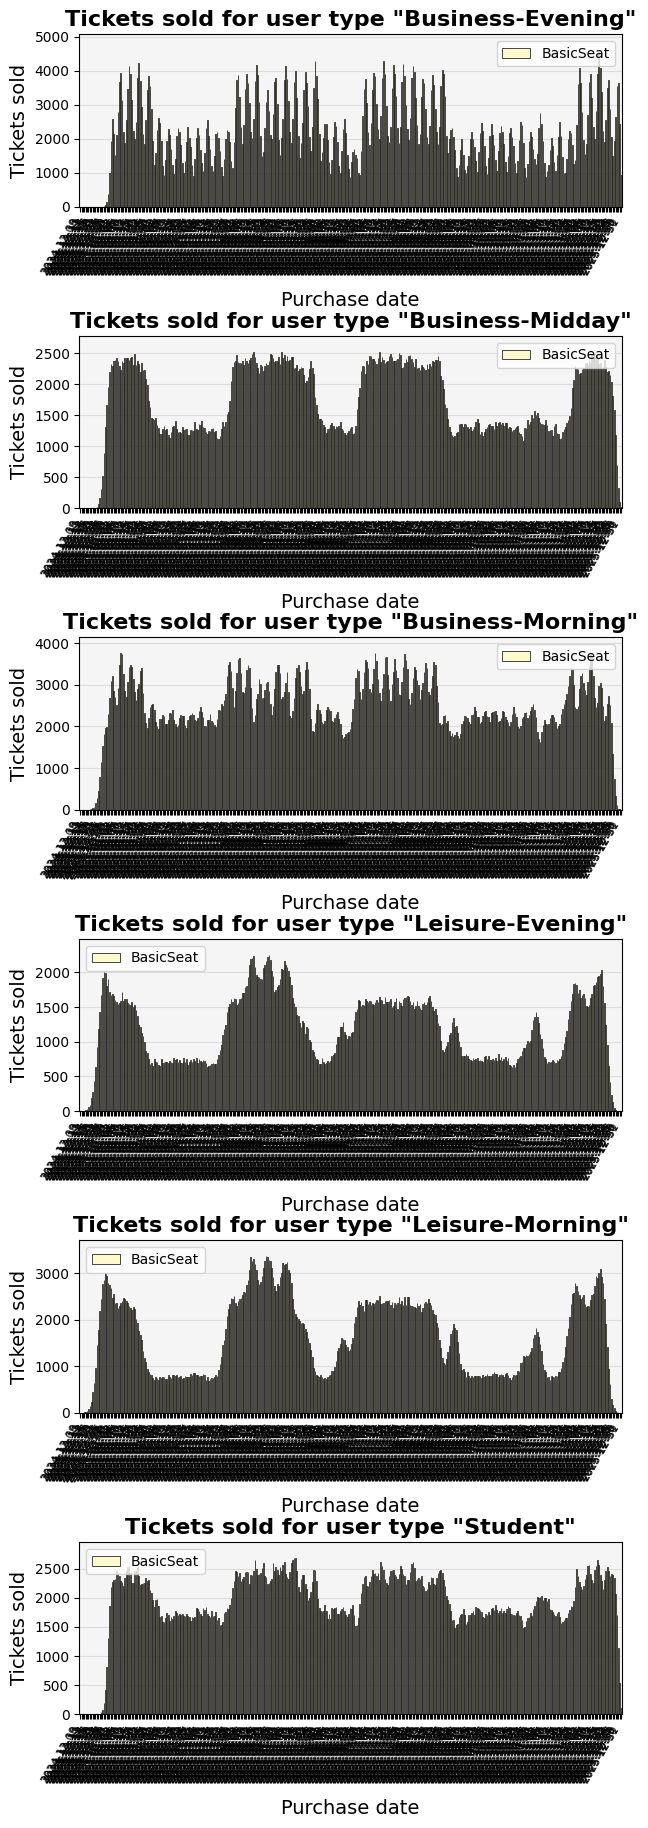

In [11]:
kernel_plotter.plot_tickets_by_user()